# Text Analytics & Sentiment on Song Lyrics (NLP Portfolio)

This notebook demonstrates **practical NLP techniques** on a small piece of text (a song excerpt).  
Because we have a *single document* (not a labeled dataset), the focus is on **text preprocessing, linguistic analysis, feature extraction, and sentiment scoring** rather than supervised classification.

## Goals
- Build a clean, reproducible preprocessing pipeline (tokenization → normalization → stopwords/lemmatization).
- Explore the text with interpretable statistics (frequency, lexical diversity, n-grams).
- Compute **sentence-level sentiment** and visualize sentiment dynamics across the text.
- Extract salient terms/phrases using TF‑IDF at the sentence level.
- Summarize insights and limitations as you would in an applied NLP project.

## 0) Setup

We import libraries and download the minimal NLTK resources needed for tokenization, stopwords and VADER sentiment.

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

from sklearn.feature_extraction.text import TfidfVectorizer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def ensure_nltk_resource(path: str, download_name: str | None = None) -> None:
    """
    Ensure an NLTK resource is available.
    - path: e.g., "tokenizers/punkt"
    - download_name: if None, defaults to last part of path ("punkt")
    """
    if download_name is None:
        download_name = path.split("/")[-1]
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(download_name)

ensure_nltk_resource("tokenizers/punkt", "punkt")
ensure_nltk_resource("tokenizers/punkt_tab", "punkt_tab")

ensure_nltk_resource("corpora/stopwords", "stopwords")

ensure_nltk_resource("sentiment/vader_lexicon", "vader_lexicon")

ensure_nltk_resource("corpora/wordnet", "wordnet")
ensure_nltk_resource("corpora/omw-1.4", "omw-1.4")


sid = SentimentIntensityAnalyzer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))


try:
    import trafilatura
except ImportError:
    !pip -q install trafilatura
    import trafilatura

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 1) Text input

We work with a short excerpt of lyrics as an example text input. In a real project, you would load text from files, APIs, or a dataset.

**Example:** extracting text from a public webpage for demonstration purposes

Sonf: Perfect
    
Autfor: Ed Sheeran
    
Text extracted from: https://www.letras.com/ed-sheeran/perfect/



In [12]:
url = "https://www.letras.com/ed-sheeran/perfect/"

downloaded = trafilatura.fetch_url(url)
if downloaded is None:
    raise ValueError("Could not download the webpage.")

text = trafilatura.extract(downloaded)
if text is None:
    raise ValueError("Could not extract main text from the webpage.")

original_text = text.strip()

print(original_text[:800])

Perfect
Ed Sheeran
I found a love for me
Darling, just dive right in and follow my lead
I found a girl, beautiful and sweet
I never knew you were the someone waiting for me
'Cause we were just kids when we fell in love
Not knowing what it was
I will not give you up this time
Darling, just kiss me slow
Your heart is all I own
And in your eyes, you're holding mine
Baby I'm, dancing in the dark
With you between my arms
Barefoot on the grass
Listening to our favourite song
When you said you looked a mess
I whispered underneath my breath
But you heard it
Darling, you look perfect tonight
I found a woman, stronger than anyone I know
She shares my dreams, I hope that someday I'll share her home
I found a lover to carry more than just my secrets
To carry love, to carry children of our own
We are s


In [3]:
print('\nCharacters:', len(text))


Characters: 1860


## 2) Preprocessing

We apply **lightweight normalization** appropriate for short, stylistic text:

- lowercase for consistent counting,
- keep alphabetic tokens (optionally keep contractions),
- remove stopwords for frequency-based analyses,
- lemmatize (optional) to group inflected forms (e.g., *waiting* → *wait*).

We keep both:
- a **raw token** view (closest to the original text), and
- a **normalized token** view (better for analysis).

In [4]:
def basic_tokenize(text: str):
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", text)

def normalize_tokens(tokens, lemmatize=True, remove_stopwords=True):
    out=[]
    for t in tokens:
        t=t.lower()
        if remove_stopwords and t in stop_words:
            continue
        if lemmatize:
            t = lemmatizer.lemmatize(t)
        out.append(t)
    return out

raw_tokens = basic_tokenize(text)
norm_tokens = normalize_tokens(raw_tokens, lemmatize=True, remove_stopwords=True)

print("Raw tokens (first 30):", raw_tokens[:30])
print("Normalized tokens (first 30):", norm_tokens[:30])
print("\n#raw tokens:", len(raw_tokens))
print("#normalized tokens:", len(norm_tokens))
print("#unique normalized tokens:", len(set(norm_tokens)))


Raw tokens (first 30): ['Perfect', 'Ed', 'Sheeran', 'I', 'found', 'a', 'love', 'for', 'me', 'Darling', 'just', 'dive', 'right', 'in', 'and', 'follow', 'my', 'lead', 'I', 'found', 'a', 'girl', 'beautiful', 'and', 'sweet', 'I', 'never', 'knew', 'you', 'were']
Normalized tokens (first 30): ['perfect', 'ed', 'sheeran', 'found', 'love', 'darling', 'dive', 'right', 'follow', 'lead', 'found', 'girl', 'beautiful', 'sweet', 'never', 'knew', 'someone', 'waiting', 'cause', 'kid', 'fell', 'love', 'knowing', 'give', 'time', 'darling', 'kiss', 'slow', 'heart', 'eye']

#raw tokens: 357
#normalized tokens: 185
#unique normalized tokens: 118


## 3) Exploratory text statistics

We compute simple descriptive statistics that are often useful in applied NLP:

- **Type–token ratio (TTR)** as a proxy for lexical diversity,
- most frequent terms (after normalization),
- Zipf-like distribution of term frequencies.


Total tokens: 185
Unique tokens: 118
Type–Token Ratio (TTR): 0.638


,token,count
0,de,6
1,perfect,5
2,darling,5
3,found,4
4,love,4
5,look,4
6,preguntas,4
7,la,4
8,baby,3
9,dancing,3


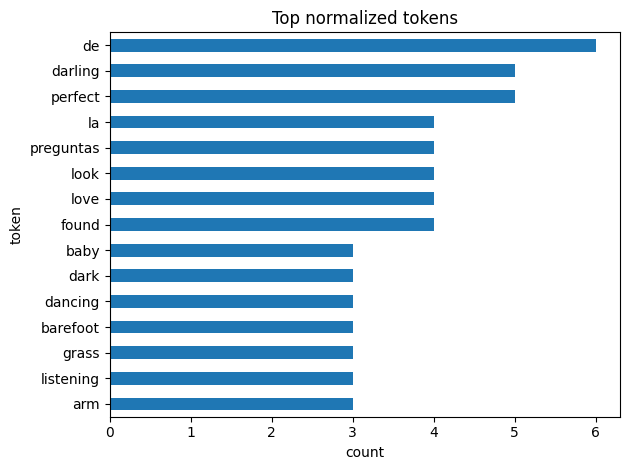

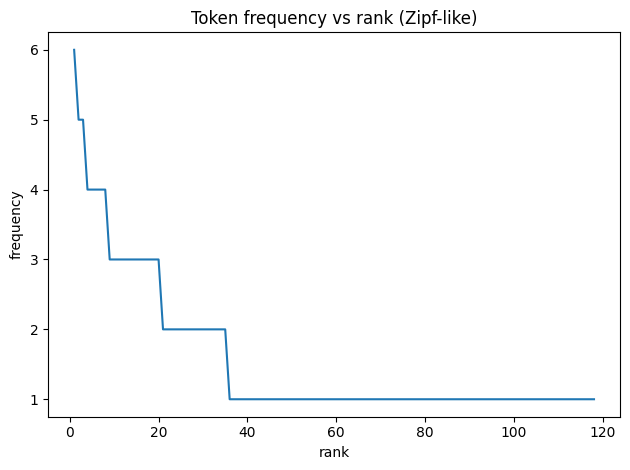

In [5]:
counts = Counter(norm_tokens)
total = sum(counts.values())
unique = len(counts)

ttr = unique / total if total else np.nan
print(f"Total tokens: {total}")
print(f"Unique tokens: {unique}")
print(f"Type–Token Ratio (TTR): {ttr:.3f}")

top_df = pd.DataFrame(counts.most_common(15), columns=["token","count"])
display(top_df)

top_df.sort_values("count").plot.barh(x="token", y="count", legend=False)
plt.title("Top normalized tokens")
plt.xlabel("count")
plt.tight_layout()
plt.show()

freqs = np.array(sorted(counts.values(), reverse=True))
ranks = np.arange(1, len(freqs)+1)
plt.plot(ranks, freqs)
plt.title("Token frequency vs rank (Zipf-like)")
plt.xlabel("rank")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()


## 4) N-grams (bigrams & trigrams)

Single-word frequencies can be dominated by common terms. N-grams often capture more meaningful patterns (e.g., short phrases).

Here we compute the most frequent **bigrams** and **trigrams** on the normalized tokens.


In [6]:
def top_ngrams(tokens, n=2, k=10):
    ng = Counter(ngrams(tokens, n))
    return pd.DataFrame(
        [(" ".join(g), c) for g,c in ng.most_common(k)],
        columns=[f"{n}-gram", "count"]
    )

display(top_ngrams(norm_tokens, n=2, k=10))
display(top_ngrams(norm_tokens, n=3, k=10))


,2-gram,count
0,look perfect,4
1,baby dancing,3
2,dancing dark,3
3,dark arm,3
4,arm barefoot,3
5,barefoot grass,3
6,grass listening,3
7,listening favourite,3
8,favourite song,3
9,perfect tonight,3


,3-gram,count
0,baby dancing dark,3
1,dancing dark arm,3
2,dark arm barefoot,3
3,arm barefoot grass,3
4,barefoot grass listening,3
5,grass listening favourite,3
6,listening favourite song,3
7,look perfect tonight,3
8,darling look perfect,2
9,perfect ed sheeran,1


## 5) Sentence-level sentiment (VADER)

VADER is a rule-based sentiment model optimized for short, informal text.  
We compute sentiment **per sentence** to observe how valence changes across the excerpt.

The main score is `compound` (range: -1 to +1).


,idx,sentence,neg,neu,pos,compound
0,1,Perfect\nEd Sheeran\nI found a love for me\nDa...,0.015,0.706,0.279,0.9986
1,2,Conoce a Letras AcademyRevisa nuestra guía de ...,0.000,1.000,0.000,0.0000
2,3,¿Enviar a la central de preguntas?,0.000,1.000,0.000,0.0000
3,4,Tus preguntas podrán ser contestadas por profe...,0.000,1.000,0.000,0.0000
4,5,Comprende mejor con esta clase:,0.000,1.000,0.000,0.0000


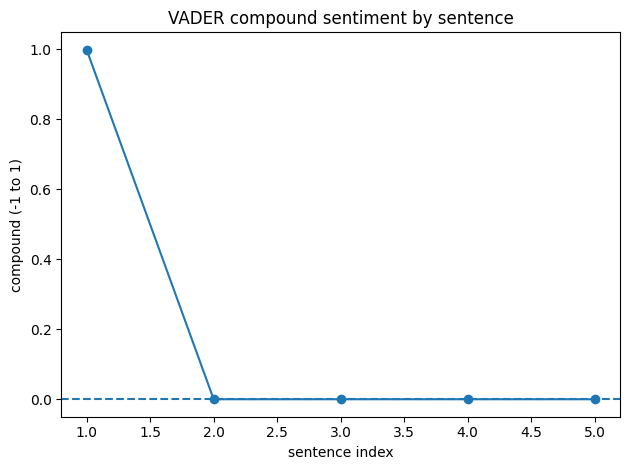

,compound
count,5.000000
mean,0.199720
std,0.446587
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.998600


In [7]:
sentences = sent_tokenize(text)
sent_scores = [sid.polarity_scores(s) for s in sentences]
sent_df = pd.DataFrame(sent_scores)
sent_df["sentence"] = sentences
sent_df["idx"] = np.arange(1, len(sent_df)+1)

display(sent_df[["idx","sentence","neg","neu","pos","compound"]])

plt.plot(sent_df["idx"], sent_df["compound"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("VADER compound sentiment by sentence")
plt.xlabel("sentence index")
plt.ylabel("compound (-1 to 1)")
plt.tight_layout()
plt.show()

# Quick summary
display(sent_df["compound"].describe())


## 6) Salient terms via TF‑IDF (sentence-level)

Even with a single document, we can treat each sentence as a “mini-document” and compute TF‑IDF across sentences.  
This highlights terms that are **more distinctive** within particular sentences (less dominated by global frequency).


In [8]:

vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"[A-Za-z]+(?:'[A-Za-z]+)?",
    stop_words="english",
    ngram_range=(1,2),
    min_df=1
)

X = vectorizer.fit_transform(sentences)
feature_names = np.array(vectorizer.get_feature_names_out())

def top_tfidf_terms(row_idx, k=8):
    row = X[row_idx].toarray().ravel()
    top_idx = np.argsort(row)[-k:][::-1]
    return list(zip(feature_names[top_idx], row[top_idx]))

rows=[]
for i,s in enumerate(sentences):
    rows.append({
        "idx": i+1,
        "sentence": s,
        "top_terms": top_tfidf_terms(i, k=6)
    })

tfidf_summary = pd.DataFrame(rows)
display(tfidf_summary)


,idx,sentence,top_terms
0,1,Perfect\nEd Sheeran\nI found a love for me\nDa...,"[(darling, 0.20800875686779333), (perfect, 0.2..."
1,2,Conoce a Letras AcademyRevisa nuestra guía de ...,"[(hacer, 0.2476747830736433), (conoce letras, ..."
2,3,¿Enviar a la central de preguntas?,"[(enviar la, 0.4117972358545618), (enviar, 0.4..."
3,4,Tus preguntas podrán ser contestadas por profe...,"[(profesores y, 0.21542548835362377), (la plat..."
4,5,Comprende mejor con esta clase:,"[(esta clase, 0.38775666010579296), (clase, 0...."


## 7) Conclusions, limitations, and next steps

### Conclusions
- The excerpt is **lexically diverse** for its length, and the most salient terms reflect themes of *love*, *commitment*, and *intimacy*.
- Sentence-level VADER scores show how sentiment can vary within a short text, which is useful when analyzing narratives or user-generated content where tone shifts over time.
- TF‑IDF at the sentence level provides a simple way to surface **distinctive phrases** even when we do not have a large corpus.

### Limitations
- This is a **single document**; results should not be generalized beyond this excerpt.
- Lexicon-based sentiment (VADER) may miss **context, figurative language, and irony**, and is not tailored to artistic text.
- Frequency-based analyses can be dominated by high-frequency terms; TF‑IDF helps, but interpretability still depends on careful preprocessing choices.

### Next steps (portfolio extensions)
If you want this notebook to demonstrate more “senior NLP” capabilities:
- Add **POS tagging / dependency parsing** and interpret how linguistic structure supports meaning (useful for behavioral text analysis).
- Compare lexicon sentiment with a **transformer-based model** (e.g., a pre-trained sentiment classifier) to discuss differences in contextual understanding.
- Scale from one text to a small corpus (multiple songs / multiple documents) to enable **topic modeling** and more robust statistical comparisons.
